In [1]:
import warnings #warnings library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #libraries imported for data analysis

In [2]:
plt.style.use('fivethirtyeight')
%matplotlib inline
warnings.filterwarnings('ignore')

In [3]:
pd.read_csv("Titanic-Dataset.csv") #titanic dataset, predicted non documented survivors based on factors like gender, age, class, fare, title, and embarked.
#data cleaning like 0,1 changed to Yes/No 1,2,3 changed to First, Second, Third, Column Labels changed, S, C, Q replaced by full city names.

,Passenger_ID,Survived,Class,Name,Gender,Age (Years),Siblings_Spouse_On_Board,Parents_Childern_On_Board,Ticket,Fare (GBP),Cabin,Embarked
0,1,No,Third,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,Southampton
1,2,Yes,First,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C85,Cherbourg
2,3,Yes,Third,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Southampton
3,4,Yes,First,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,C123,Southampton
4,5,No,Third,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,Southampton
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,Third,"Spector, Mr. Woolf",Male,NaN,0,0,A.5. 3236,8.0500,NaN,Southampton
1305,1306,NaN,First,"Oliva y Ocana, Dona. Fermina",Female,39.0,0,0,PC 17758,108.9000,C105,Cherbourg
1306,1307,NaN,Third,"Saether, Mr. Simon Sivertsen",Male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,Southampton
1307,1308,NaN,Third,"Ware, Mr. Frederick",Male,NaN,0,0,359309,8.0500,NaN,Southampton


In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv') #Train-Test Split, 1-891 for training, 892-1309 for testing.

In [5]:
train.shape #number of rows, columns

(891, 12)

In [6]:
train.info()  #information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Passenger_ID               891 non-null    int64  
 1   Survived                   891 non-null    object 
 2   Class                      891 non-null    object 
 3   Name                       891 non-null    object 
 4   Gender                     891 non-null    object 
 5   Age (Years)                714 non-null    float64
 6   Siblings_Spouse_On_Board   891 non-null    int64  
 7   Parents_Childern_On_Board  891 non-null    int64  
 8   Ticket                     891 non-null    object 
 9   Fare (GBP)                 891 non-null    float64
 10  Cabin                      204 non-null    object 
 11  Embarked                   891 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [7]:
train.isnull().sum() #null values

Passenger_ID                   0
Survived                       0
Class                          0
Name                           0
Gender                         0
Age (Years)                  177
Siblings_Spouse_On_Board       0
Parents_Childern_On_Board      0
Ticket                         0
Fare (GBP)                     0
Cabin                        687
Embarked                       0
dtype: int64

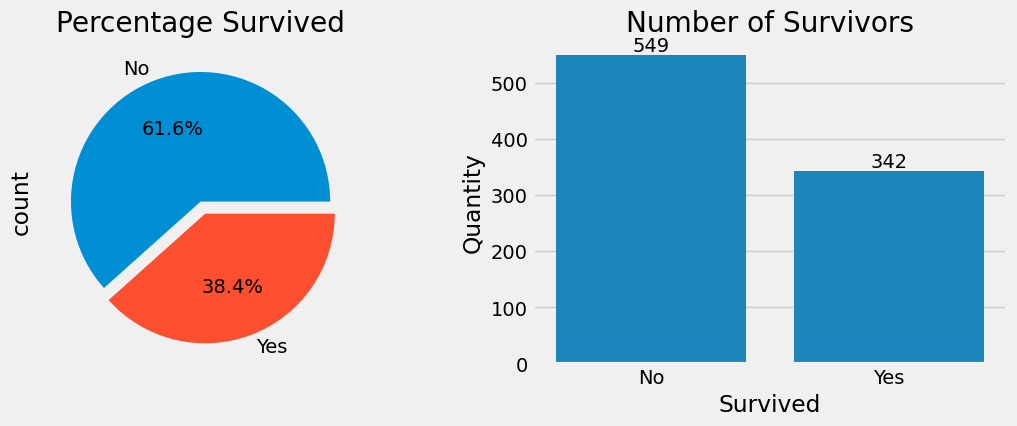

In [8]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
train['Survived'].value_counts().plot.pie( 
	explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False) 
ax[0].set_title('Percentage Survived') 
 #pie chart 
sns.countplot(x='Survived', data=train, ax=ax[1])
ax[1].bar_label(ax[1].containers[0])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Number of Survivors') #bar chart
plt.show() 

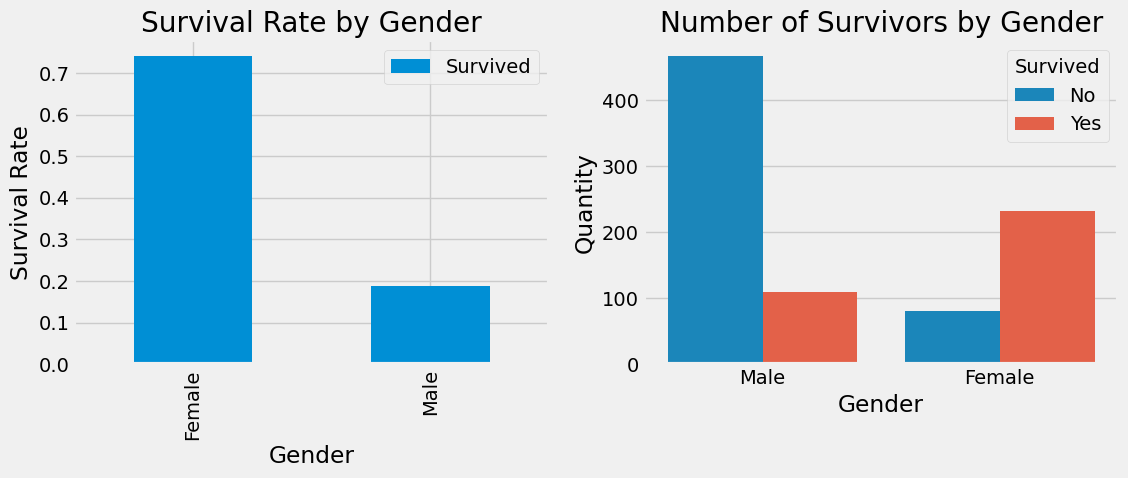

In [9]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
(train.assign(Survived= train['Survived'].eq('Yes'))
     [['Gender', 'Survived']]
     .groupby(['Gender']).mean()
     .plot.bar(ax=ax[0])) #gender comparison of survival rate and number of survivors by gender
ax[0].set_title('Survival Rate by Gender') 
ax[0].set_ylabel('Survival Rate')
sns.countplot(x='Gender', hue='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Number of Survivors by Gender') 
plt.show()

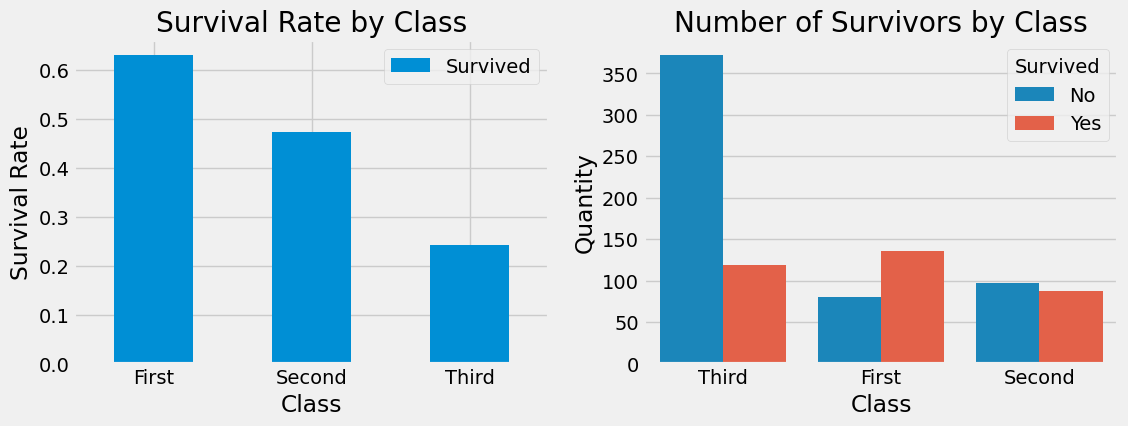

In [10]:
f,ax = plt.subplots(1, 2, figsize=(12, 4))
(train.assign(Survived= train['Survived'].eq('Yes'))
     [['Class', 'Survived']]
     .groupby(['Class']).mean()
     .plot.bar(ax=ax[0])) #class comparison of survival rate and number of survivors by class
ax[0].set_title('Survival Rate by Class') 
ax[0].set_ylabel('Survival Rate')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
sns.countplot(x='Class', hue='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Number of Survivors by Class') 
plt.show()

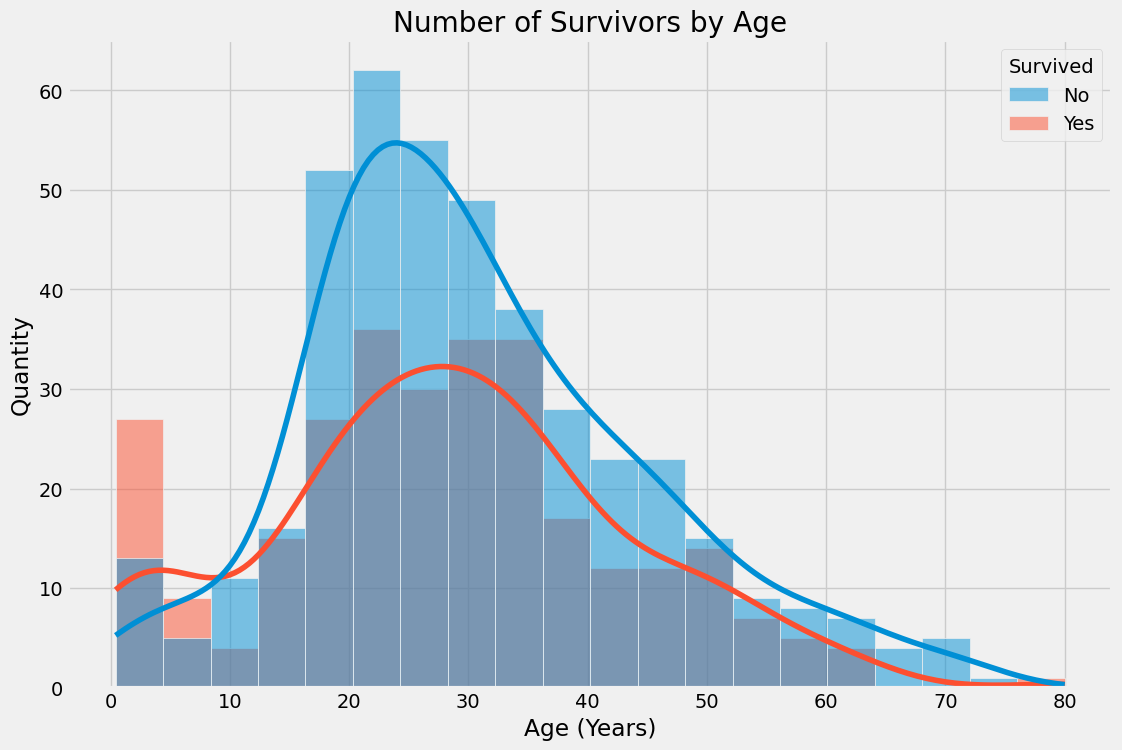

In [11]:
f, ax = plt.subplots(1, 1, figsize=(12, 8))
#age comparison of number of survivors by age
sns.histplot(x='Age (Years)', hue='Survived', data=train, ax=ax, bins=20, kde=True)
ax.set_ylabel('Quantity') 
ax.set_title('Number of Survivors by Age')
plt.show()

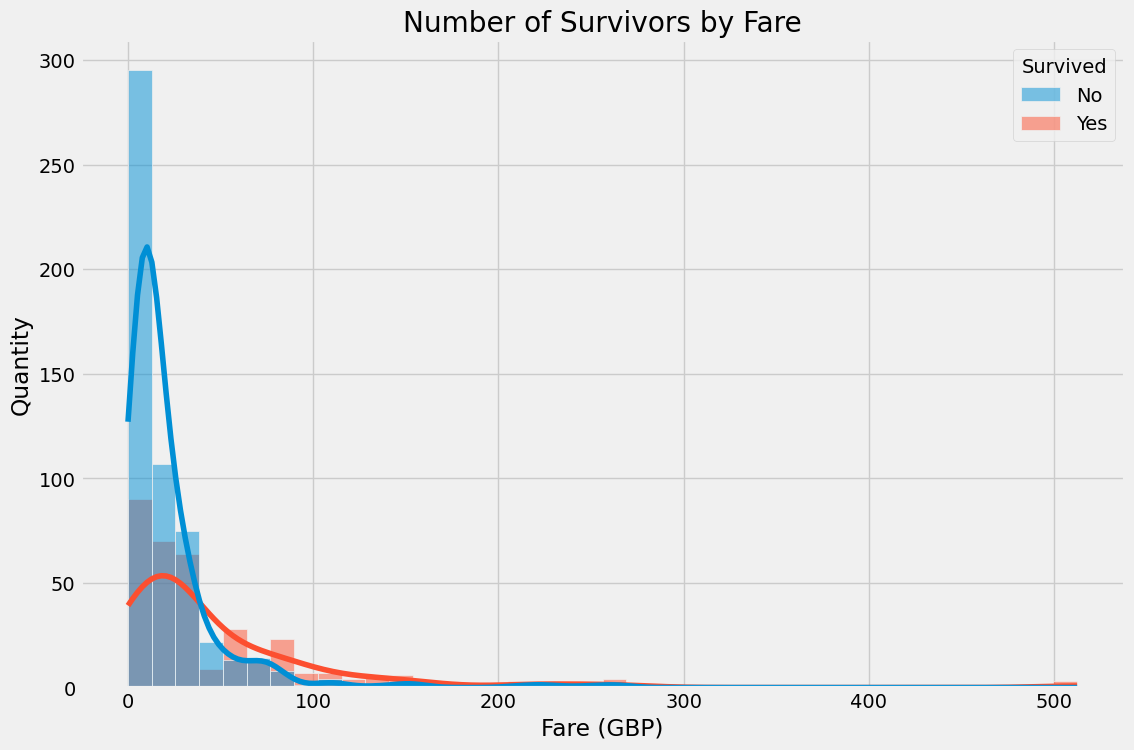

In [12]:
f,ax = plt.subplots(1, 1, figsize=(12, 8))
#fare comparison of number of survivors by fare
sns.histplot(x='Fare (GBP)', hue='Survived', data=train, ax=ax, bins=40, kde=True)
ax.set_title('Number of Survivors by Fare') 
ax.set_ylabel('Quantity')
plt.show()

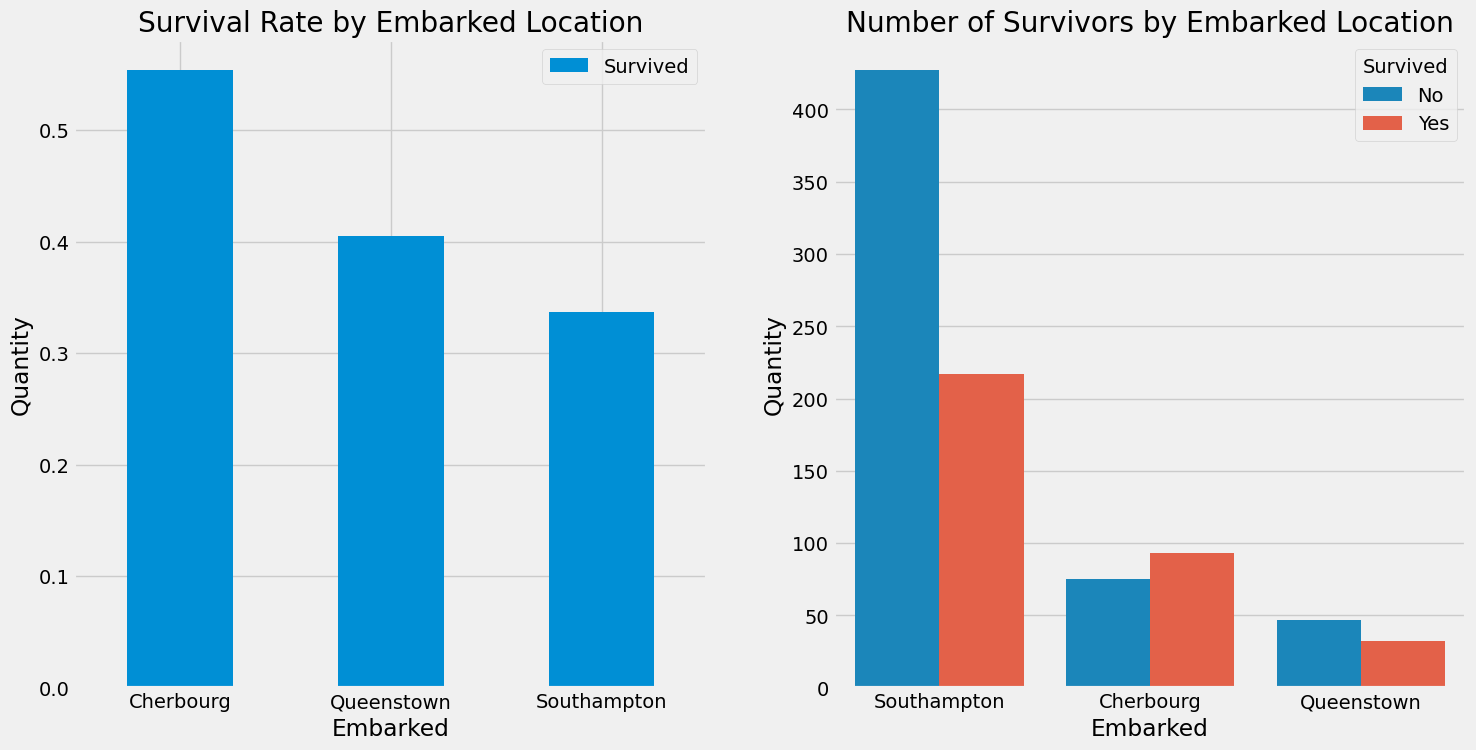

In [13]:
f, ax = plt.subplots(1, 2, figsize=(16, 8))
(train.assign(Survived= train['Survived'].eq('Yes'))
     [['Embarked', 'Survived']]
     .groupby(['Embarked']).mean()
     .plot.bar(ax=ax[0])) #embarked comparison of survival rate and number of survivors by embarked location
ax[0].set_title('Survival Rate by Embarked Location')
ax[0].set_ylabel('Quantity')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
sns.countplot(x='Embarked', hue='Survived', data=train, ax=ax[1])
ax[1].set_title('Number of Survivors by Embarked Location') 
ax[1].set_ylabel('Quantity')
plt.show()

In [14]:
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)  #feature engineering, optimising data for model training, for example remove unwanted columns like the Cabin.

In [15]:
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1) #remove Ticket column

In [16]:
train = train.fillna({"Embarked": "Southampton"}) # replacing the missing values in the Embarked feature with Southampton

In [17]:
train["Age"] = train["Age (Years)"].fillna(-0.5)
test["Age"] = test["Age (Years)"].fillna(-0.5)
bins = [-1, 0, 5, 12, 20, 24, 40, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Older Adult', 'Senior Citizen']
train['AgeGroup'] = pd.cut(train["Age (Years)"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age (Years)"], bins, labels=labels) #sort the ages into categories

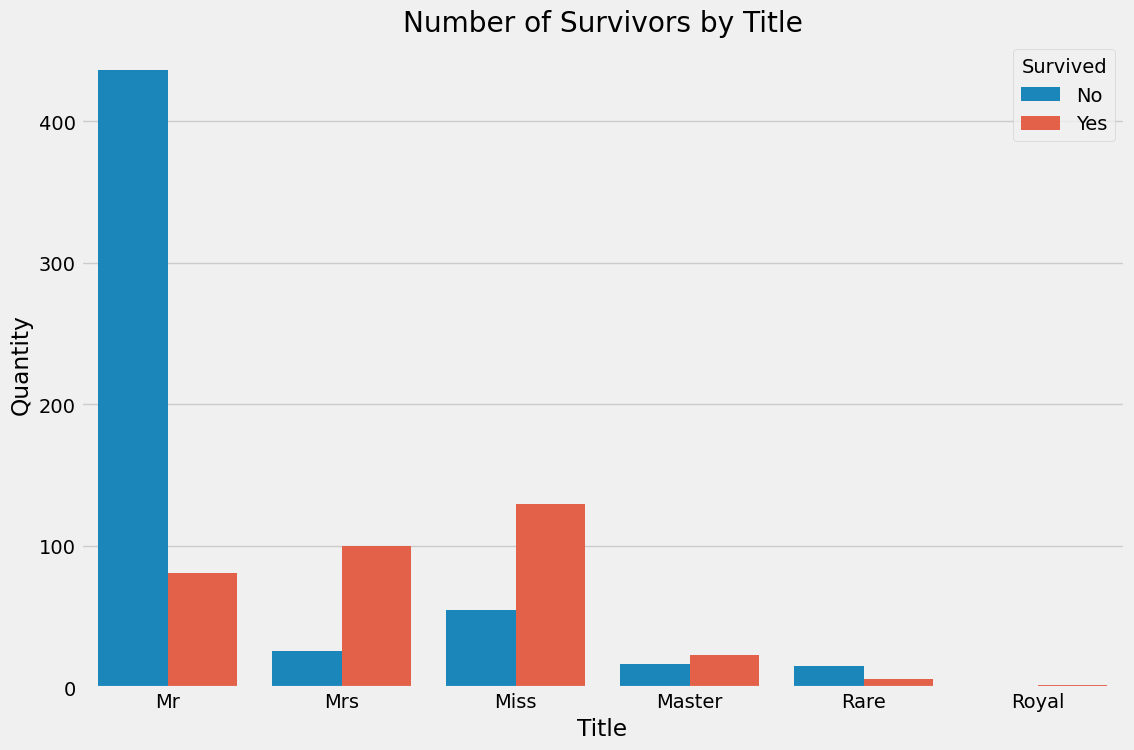

In [18]:
combine = [train, test] #combined group
Survived = {"Yes": 1, "No": 0} #yes no mapping
for dataset in combine:
    if "Survived" in dataset.columns:
        dataset["Survived"] = (
            dataset["Survived"]
            .astype(str)
            .str.strip()
            .map(Survived)
        )

for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
pd.crosstab(train['Title'], train['Gender']) #extract title 
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                 'Don', 'Dr', 'Major',
                                                 'Rev', 'Jonkheer', 'Dona'],
                                                'Rare') #replace uncmmon titles with rare
    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal') #replace different royal titles with royal
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

f,ax = plt.subplots(1, 1, figsize=(12, 8))
#title comparison of number of survivors by title
sns.countplot(x='Title', hue='Survived', data=train.replace({'Survived': {0: 'No', 1: 'Yes'}}), ax=ax)
ax.set_title('Number of Survivors by Title')
ax.set_ylabel('Quantity')
plt.show()

In [19]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6} #map each into numerical values
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

In [20]:
mr_age = train[train["Title"] == 1]["AgeGroup"].mode()  # Young Adult
miss_age = train[train["Title"] == 2]["AgeGroup"].mode()  # Student
mrs_age = train[train["Title"] == 3]["AgeGroup"].mode()  # Older Adult
master_age = train[train["Title"] == 4]["AgeGroup"].mode()  # Baby
royal_age = train[train["Title"] == 5]["AgeGroup"].mode()  # Older Adult
rare_age = train[train["Title"] == 6]["AgeGroup"].mode()  # Older Adult

age_title_mapping = {1: "Young Adult", 2: "Student",
                     3: "Older Adult", 4: "Baby", 5: "Older Adult", 6: "Older Adult"}

for x in range(len(train["AgeGroup"])):
    if train["AgeGroup"][x] == "Unknown":
        train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]

for x in range(len(test["AgeGroup"])):
    if test["AgeGroup"][x] == "Unknown":
        test["AgeGroup"][x] = age_title_mapping[test["Title"][x]]

In [21]:
age_mapping = {'Baby': 1, 'Child': 2, 'Teenager': 3,
               'Student': 4, 'Young Adult': 5, 'Older Adult': 6, 
               'Senior Citizen': 7}
train['AgeGroup'] = train['AgeGroup'].map(age_mapping)
test['AgeGroup'] = test['AgeGroup'].map(age_mapping)

train.head()
train = train.drop(['Age (Years)'], axis=1) #age map
test = test.drop(['Age (Years)'], axis=1)

In [22]:
train = train.drop(['Name'], axis=1) #remove Name
test = test.drop(['Name'], axis=1)

In [23]:
gender_mapping = {"Male": 0, "Female": 1}
train['Gender'] = train['Gender'].map(gender_mapping)
test['Gender'] = test['Gender'].map(gender_mapping) #map gender

embarked_mapping = {"Southampton": 1, "Cherbourg": 2, "Queenstown": 3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)  #map embarked for assingning numericals

In [24]:
for x in range(len(test["Fare (GBP)"])):
    if pd.isnull(test["Fare (GBP)"][x]):
        pclass = test["Class"][x]  #fill in missing fare, third class if null
        test["Fare (GBP)"][x] = round(
            train[train["Class"] == pclass]["Fare (GBP)"].mean(), 4)


train['FareBand'] = pd.qcut(train['Fare (GBP)'], 4, 
                            labels=[1, 2, 3, 4])  #fare mapping
test['FareBand'] = pd.qcut(test['Fare (GBP)'], 4, 
                           labels=[1, 2, 3, 4])

train = train.drop(['Fare (GBP)'], axis=1) 
test = test.drop(['Fare (GBP)'], axis=1)

In [25]:
#map class
class_mapping = {"Third": 3, "Second": 2,"First":1}
train['Class'] = train['Class'].map(class_mapping)
test['Class'] = test['Class'].map(class_mapping) 

In [26]:
from sklearn.model_selection import train_test_split
predictors = train.drop(['Survived', 'Passenger_ID'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)  #train model 80% train 20% test 

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score  #model selection 
#random forest used
randomforest = RandomForestClassifier(n_estimators=100, random_state=42) #it is a supervised machine learning algorithm where multiple decision trees are used
#accuracy remaines same
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)

acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest) #performance evaluation for accuracy

83.8


In [28]:
ids = test['Passenger_ID']
predictions = randomforest.predict(test.drop('Passenger_ID', axis=1))
output = pd.DataFrame({'Passenger_ID': ids, 'Survived': predictions}) #predict the data 

In [29]:
output #output of ID and predictions

,Passenger_ID,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [30]:
output.to_csv('resultfile.csv', index=False) #output csv 

In [31]:
train

,Passenger_ID,Survived,Class,Gender,Siblings_Spouse_On_Board,Parents_Childern_On_Board,Embarked,Age,AgeGroup,Title,FareBand
0,1,0,3,0,1,0,1,22.0,4.0,1,1
1,2,1,1,1,1,0,2,38.0,5.0,3,4
2,3,1,3,1,0,0,1,26.0,5.0,2,2
3,4,1,1,1,1,0,1,35.0,5.0,3,4
4,5,0,3,0,0,0,1,35.0,5.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,0,0,1,27.0,5.0,6,2
887,888,1,1,1,0,0,1,19.0,3.0,2,3
888,889,0,3,1,1,2,1,-0.5,NaN,2,3
889,890,1,1,0,0,0,2,26.0,5.0,1,3


In [32]:
test

,Passenger_ID,Class,Gender,Siblings_Spouse_On_Board,Parents_Childern_On_Board,Embarked,Age,AgeGroup,Title,FareBand
0,892,3,0,0,0,3,34.5,5.0,1,1
1,893,3,1,1,0,1,47.0,6.0,3,1
2,894,2,0,0,0,3,62.0,7.0,1,2
3,895,3,0,0,0,1,27.0,5.0,1,2
4,896,3,1,1,1,1,22.0,4.0,3,2
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0,0,1,-0.5,NaN,1,2
414,1306,1,1,0,0,2,39.0,5.0,6,4
415,1307,3,0,0,0,1,38.5,5.0,1,1
416,1308,3,0,0,0,1,-0.5,NaN,1,2


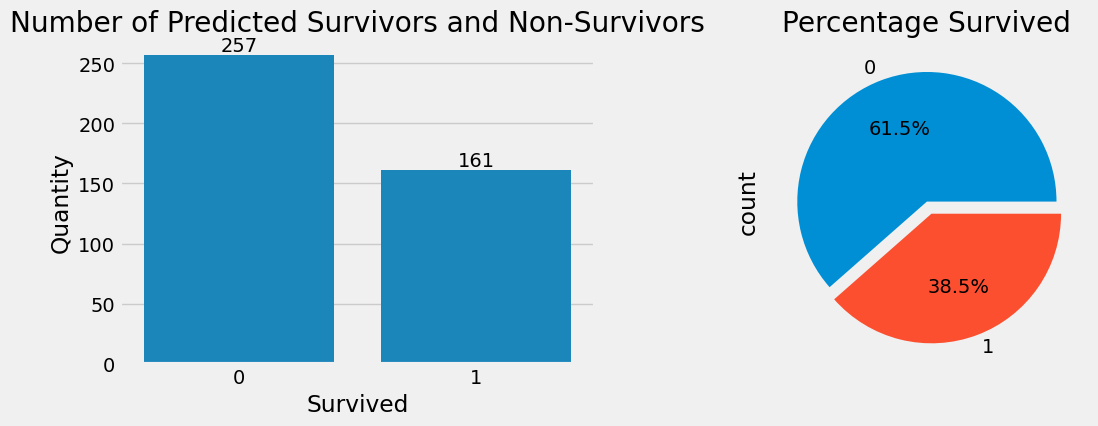

In [33]:
f,ax= plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Survived', data=output, ax=ax[0])
ax[0].set_title('Number of Predicted Survivors and Non-Survivors')
ax[0].set_ylabel('Quantity')
ax[0].bar_label(ax[0].containers[0])
output['Survived'].value_counts().plot.pie( 
explode=[0, 0.1], autopct='%1.1f%%', ax=ax[1], shadow=False) 
ax[1].set_title('Percentage Survived') 
plt.show()